# 신경과 재진 외래 AI 문진 — LLM 프롬프트 평가

## 결론

이 노트북은 비식별 합성 사례(치매·파킨슨병·뇌전증 재진 외래)에서 프롬프트 v0~v3의 정보 추출 성능을 비교한다. `frontend/`는 이 구조화 결과가 실제 문진 화면에 어떻게 쓰일지 보여주는 UI 프로토타입이며, NLP·LLM 실험은 이 노트북에서 수행한다. Flask(`legacy_flask/`)는 현재 범위 밖의 백엔드 후보 예시일 뿐이다.

평가 지표: Exact Match, Field Accuracy, Micro Precision/Recall/F1, 오류 유형 분석(누락 오류·과잉 추론·분류 오류·표현 오류·형식 오류)

실행 순서:

1. 환경 설정
2. API 키 입력
3. 사례와 프롬프트 확인
4. 사례 1개로 smoke test
5. 개발 세트에서 v0~v3 비교
6. 오류 분석과 프롬프트 수정
7. 선정된 프롬프트만 시험 세트에서 최종 평가, `results/`에 결과 저장


## 0. 데이터 사용 원칙

- 실제 환자의 이름, 생년월일, 등록번호, 연락처, 진료일을 입력하지 않는다.
- 외래 경험을 바탕으로 작성한 비식별 합성 문장만 사용한다.
- API 키는 코드에 직접 작성하거나 Git에 커밋하지 않는다.
- 사례 30개(개발 20/시험 10) 결과는 소규모 평가로 해석한다.


In [1]:
# 최초 한 번만 실행합니다. 설치 후 커널 재시작 안내가 나오면 재시작합니다.
%pip install -q openai python-dotenv pandas matplotlib langsmith

Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import os
import re
from datetime import datetime
from getpass import getpass
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()
pd.set_option("display.max_colwidth", 120)
print("환경 설정 완료")

환경 설정 완료


## 1. API 키 설정

로컬 프로젝트의 `.env`에 키가 있으면 자동으로 읽는다. 코랩처럼 `.env`가 없는 환경에서는 아래 셀 실행 후 입력창에 키를 붙여넣는다. 입력 내용은 화면에 표시되지 않는다.

In [3]:
if not os.getenv("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass("OPENAI_API_KEY 입력: ")

# .env에 LANGSMITH_API_KEY가 있으면 모든 OpenAI 호출이 LangSmith에 자동 트레이싱된다.
# 키가 없으면 로컬 실행만 하며, 이후 셀은 모두 동일하게 동작한다.
if os.getenv("LANGSMITH_API_KEY"):
    os.environ.setdefault("LANGSMITH_TRACING", "true")
    os.environ.setdefault("LANGSMITH_PROJECT", "outpatient-ai-lab")
    from langsmith.wrappers import wrap_openai
    client = wrap_openai(OpenAI())
    print("API 키 설정 완료 — LangSmith 트레이싱 켜짐 (project: outpatient-ai-lab)")
else:
    client = OpenAI()
    print("API 키 설정 완료 — LangSmith 미사용")

API 키 설정 완료 — LangSmith 트레이싱 켜짐 (project: outpatient-ai-lab)


## 2. 실험 설정

프롬프트 비교 중에는 모델을 고정한다. 모델 비교는 최종 프롬프트를 결정한 후 별도 실험으로 수행한다.

In [4]:
MODEL = os.getenv("OPENAI_MODEL", "gpt-4.1-mini")
MAX_OUTPUT_TOKENS = 500
TEMPERATURE_NOTE = "Responses API 기본 설정 사용"

print({
    "model": MODEL,
    "max_output_tokens": MAX_OUTPUT_TOKENS,
    "temperature": TEMPERATURE_NOTE,
})

{'model': 'gpt-4.1-mini', 'max_output_tokens': 500, 'temperature': 'Responses API 기본 설정 사용'}


## 3. 사례와 프롬프트 불러오기

노트북을 프로젝트 폴더에서 열면 `eval_cases.json`과 `prompts.py`를 자동으로 읽는다. 코랩에서는 다음 셀을 실행한 뒤 두 파일을 업로드한다.

In [5]:
# 코랩에서만 실행합니다. 로컬 Jupyter에서는 실행하지 않아도 됩니다.
try:
    from google.colab import files
    print("eval_cases.json과 prompts.py를 선택하세요.")
    uploaded = files.upload()
except ImportError:
    print("로컬 Jupyter 환경입니다. 프로젝트 폴더의 파일을 사용합니다.")

로컬 Jupyter 환경입니다. 프로젝트 폴더의 파일을 사용합니다.


In [6]:
def find_project_dir():
    candidates = [Path.cwd(), Path.cwd() / "outputs" / "outpatient-ai-lab"]
    for candidate in candidates:
        if (candidate / "eval_cases.json").exists() and (candidate / "prompts.py").exists():
            return candidate
    raise FileNotFoundError(
        "eval_cases.json과 prompts.py를 찾지 못했습니다. "
        "노트북을 outpatient-ai-lab 폴더에서 실행하세요."
    )

PROJECT_DIR = find_project_dir()
RESULTS_DIR = PROJECT_DIR / "results"
RAW_DIR = RESULTS_DIR / "raw"
RESULTS_DIR.mkdir(exist_ok=True)
RAW_DIR.mkdir(exist_ok=True)

print("프로젝트 폴더:", PROJECT_DIR)
print("결과 저장 폴더:", RESULTS_DIR)


프로젝트 폴더: /Users/mac/Documents/Project/outpatient-ai-lab
결과 저장 폴더: /Users/mac/Documents/Project/outpatient-ai-lab/results


In [7]:
import sys

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from prompts import ALLOWED_VALUES, PROMPT_VERSIONS

with (PROJECT_DIR / "eval_cases.json").open(encoding="utf-8") as file:
    EVAL_CASES = json.load(file)

print("사례 수:", len(EVAL_CASES))
print("프롬프트 버전:", list(PROMPT_VERSIONS))

사례 수: 30
프롬프트 버전: ['v0', 'v1', 'v2', 'v3']


In [8]:
case_table = pd.DataFrame([
    {
        "case_id": case["case_id"],
        "disease_context": case.get("disease_context", ""),
        "split": case["split"],
        "input": case["input"],
        "gold": json.dumps(case["gold"], ensure_ascii=False),
    }
    for case in EVAL_CASES
])
case_table


,case_id,disease_context,split,input,gold
0,case_001,치매,development,어머니는 오늘 못 오시고 저만 왔어요. 요양원에 낼 서류가 필요한데 뭘 떼야 하는지는 잘 모르겠어요. 그리고 요즘 식사를 하시고도 밥을 안 먹었다고 하시는 일이 자꾸 있어서 그것도 여쭤보고 싶어요.,"{""visit_purpose"": [""서류 발급"", ""증상 상담""], ""symptom_change"": ""나빠짐"", ""document_type"": [""기타/종류 모름""], ""document_destination""..."
1,case_002,파킨슨병,development,약은 그대로 받을게요. 그런데 요즘 손 떨림이 오전에는 괜찮다가 오후만 되면 심해져요. 저녁때는 수저 들기가 힘들 때도 있고요. 혼자 왔습니다.,"{""visit_purpose"": [""약 처방"", ""증상 상담""], ""symptom_change"": ""나빠짐"", ""document_type"": [], ""document_destination"": [], ""pati..."
2,case_003,뇌전증,development,"지난달에 학교 낼 진단서는 받아 갔고요, 요즘 발작 횟수가 좀 는 것 같아서 왔어요. 엄마랑 같이 왔습니다.","{""visit_purpose"": [""증상 상담""], ""symptom_change"": ""나빠짐"", ""document_type"": [], ""document_destination"": [], ""patient_pres..."
3,case_004,치매,development,"아버지 모시고 같이 왔어요. 지난번 검사 결과 들으러 왔고, 보험에 낼 소견서도 하나 부탁드립니다.","{""visit_purpose"": [""검사결과 확인"", ""서류 발급""], ""symptom_change"": null, ""document_type"": [""소견서""], ""document_destination"": [""..."
4,case_005,파킨슨병,development,"아버지는 거동이 불편하셔서 저만 왔어요. 장애 등급 신청을 하려는데 어떤 서류를 떼야 하는지 모르겠어요. 그리고 요즘 걸음이 많이 느려지셨어요. 발이 잘 안 떨어진다고 하시고, 집 안에서도 몇 번 넘어질 뻔했어요.","{""visit_purpose"": [""서류 발급"", ""증상 상담""], ""symptom_change"": ""나빠짐"", ""document_type"": [""기타/종류 모름""], ""document_destination""..."
5,case_006,뇌전증,development,약만 타러 왔어요. 별다른 건 없었고요. 혼자 왔습니다.,"{""visit_purpose"": [""약 처방""], ""symptom_change"": ""비슷함"", ""document_type"": [], ""document_destination"": [], ""patient_prese..."
6,case_007,치매,development,어머니 모시고 같이 왔어요. 요즘 밤에 자꾸 깨서 집 안을 돌아다니세요. 새벽에 현관문을 열려고 하신 적도 있고요. 이게 약 때문인지 다른 이유인지 상담받고 싶어요.,"{""visit_purpose"": [""증상 상담""], ""symptom_change"": ""새 증상 있음"", ""document_type"": [], ""document_destination"": [], ""patient_..."
7,case_008,파킨슨병,test,제가 환자예요. 다른 병원으로 옮기려고 진료기록이랑 검사 결과지 받으러 왔어요. 증상은 예전이랑 비슷해요.,"{""visit_purpose"": [""서류 발급""], ""symptom_change"": ""비슷함"", ""document_type"": [""기록/결과 사본""], ""document_destination"": [""타 의료기..."
8,case_009,뇌전증,test,발작이 요즘 잦습니다. 약을 조절해야 하나 싶어서요. 오늘은 보호자만 왔어요.,"{""visit_purpose"": [""증상 상담"", ""약 처방""], ""symptom_change"": ""나빠짐"", ""document_type"": [], ""document_destination"": [], ""pati..."
9,case_010,치매,test,"지난번 인지 검사 결과 들으러 왔고요, 보험사에 낼 진단서랑 산정특례 연장도 해야 합니다. 개인적으로 쓸 서류에 의사 확인도 하나 받고 싶은데 어디 낼지는 아직 못 정했어요. 상태는 좋아진 건지 나빠진 건지 ...","{""visit_purpose"": [""검사결과 확인"", ""서류 발급""], ""symptom_change"": ""잘 모르겠음"", ""document_type"": [""진단서"", ""기타/종류 모름"", ""개인 양식""], ""..."


### 사례 수정 방법

`eval_cases.json`에서 `input`과 `gold`를 수정한 후 위의 불러오기 셀부터 다시 실행한다. `input`에는 정돈되지 않은 구어체를 작성하고, `gold`에는 원문에서 직접 확인할 수 있는 값만 기록한다.

In [9]:
for version, prompt in PROMPT_VERSIONS.items():
    print(f"\n===== {version} =====")
    print(prompt)


===== v0 =====
너는 신경과 재진 외래 진료 전 문진 내용을 정리하는 의료 코디네이터다.
진단하거나 치료 방침을 제안하지 않는다.
환자 또는 보호자가 말한 내용을 바탕으로 진료 전 확인에 필요한 정보를 구조화한다.
확실하지 않은 내용은 추측하지 말고 '미상' 또는 원문 표현을 유지한다.
반드시 지정된 JSON 형식으로만 출력한다.

===== v1 =====
너는 신경과 재진 외래 진료 전 문진 내용을 정리하는 의료 코디네이터다.
진단하거나 치료 방침을 제안하지 않는다.
환자 또는 보호자가 말한 내용을 바탕으로 진료 전 확인에 필요한 정보를 구조화한다.
확실하지 않은 내용은 추측하지 말고 '미상' 또는 원문 표현을 유지한다.
반드시 지정된 JSON 형식으로만 출력한다.

다음 필드를 추출해 JSON으로 출력한다.

- visit_purpose: 약 처방, 증상 상담, 서류 발급, 검사결과 확인 중 해당하는 값을 배열로 작성
- symptom_change: 좋아짐, 비슷함, 나빠짐, 새 증상 있음, 잘 모르겠음 중 하나. 언급 없으면 null
- document_type: 진단서, 소견서, 통원사실증명서(진료확인서), 기록/결과 사본, 개인 양식, 기타/종류 모름 중 해당하는 값을 배열로 작성. 요청 없으면 빈 배열
- document_destination: 보험, 직장/학교, 공공기관, 타 의료기관/요양기관, 개인 보관, 제출처 모름 중 해당하는 값을 배열로 작성. 요청 없으면 빈 배열
- patient_present: 환자 본인이 오늘 진료에 present하면 true, present하지 않으면 false
- guardian_only: 보호자만 내원하고 환자는 오지 않았으면 true, 아니면 false
- subjective_summary: 환자 또는 보호자가 말한 내용을 진단·치료 방침 없이 1~2문장으로 구조화한 요약
- requested_consultation: 오늘 진료 중 상담받고 싶다고 밝힌 구체적 내용. 없으면 null
- soap_

## 4. LLM 호출과 평가 함수

아래 셀은 실행 함수 정의다. 셀을 실행해도 아직 API 호출은 발생하지 않는다.

In [10]:
from prompts import MULTI_LABEL_FIELDS, SINGLE_LABEL_FIELDS, FREE_TEXT_FIELDS

ALL_CLASSIFICATION_FIELDS = MULTI_LABEL_FIELDS + SINGLE_LABEL_FIELDS


def parse_json_object(raw_text):
    cleaned = raw_text.strip()
    if cleaned.startswith("```"):
        cleaned = re.sub(r"^```(?:json)?", "", cleaned).strip()
        cleaned = re.sub(r"```$", "", cleaned).strip()
    start = cleaned.find("{")
    end = cleaned.rfind("}")
    if start == -1 or end == -1:
        raise ValueError("JSON 객체를 찾지 못했습니다.")
    return json.loads(cleaned[start:end + 1])


def normalize_prediction(payload):
    normalized = {}

    for field in MULTI_LABEL_FIELDS:
        value = payload.get(field, [])
        if isinstance(value, str):
            value = [value]
        if not isinstance(value, list):
            value = []
        normalized[field] = [str(item).strip() for item in value if str(item).strip()]

    for field in ("symptom_change",):
        value = payload.get(field)
        normalized[field] = str(value).strip() if value not in (None, "") else None

    for field in ("patient_present", "guardian_only"):
        value = payload.get(field)
        normalized[field] = bool(value) if isinstance(value, bool) else None

    for field in FREE_TEXT_FIELDS:
        value = payload.get(field)
        normalized[field] = str(value).strip() if value not in (None, "") else None

    return normalized


In [11]:
def run_llm(case, version):
    response = client.responses.create(
        model=MODEL,
        instructions=PROMPT_VERSIONS[version],
        input=(
            f"환자 또는 보호자 입력:\n{case['input']}\n\n"
            f"허용값:\n{json.dumps(ALLOWED_VALUES, ensure_ascii=False)}"
        ),
        max_output_tokens=MAX_OUTPUT_TOKENS,
    )

    raw_output = response.output_text
    usage = {
        "input_tokens": getattr(response.usage, "input_tokens", None),
        "output_tokens": getattr(response.usage, "output_tokens", None),
        "total_tokens": getattr(response.usage, "total_tokens", None),
    }

    try:
        prediction = normalize_prediction(parse_json_object(raw_output))
        return prediction, raw_output, None, usage
    except Exception as error:
        return None, raw_output, str(error), usage


In [12]:
def safe_divide(numerator, denominator):
    return numerator / denominator if denominator else 0.0


def empty_prediction():
    return {
        **{field: [] for field in MULTI_LABEL_FIELDS},
        "symptom_change": None,
        "patient_present": None,
        "guardian_only": None,
        **{field: None for field in FREE_TEXT_FIELDS},
    }


def field_is_correct(field, prediction, gold):
    if field in MULTI_LABEL_FIELDS:
        return set(prediction.get(field) or []) == set(gold.get(field) or [])
    return prediction.get(field) == gold.get(field)


def score_records(records):
    counts = {field: {"tp": 0, "fp": 0, "fn": 0} for field in MULTI_LABEL_FIELDS}
    single_correct = {field: 0 for field in SINGLE_LABEL_FIELDS}
    field_correct_total = 0
    field_total = 0
    exact_match_count = 0
    valid_count = 0

    for record in records:
        gold = record["gold"]
        prediction = record["prediction"]
        if prediction is not None:
            valid_count += 1
        else:
            prediction = empty_prediction()

        record_all_correct = True
        for field in MULTI_LABEL_FIELDS:
            gold_set = set(gold.get(field) or [])
            predicted_set = set(prediction.get(field) or [])
            counts[field]["tp"] += len(gold_set & predicted_set)
            counts[field]["fp"] += len(predicted_set - gold_set)
            counts[field]["fn"] += len(gold_set - predicted_set)

        for field in ALL_CLASSIFICATION_FIELDS:
            correct = field_is_correct(field, prediction, gold)
            field_total += 1
            field_correct_total += int(correct)
            if not correct:
                record_all_correct = False
            if field in SINGLE_LABEL_FIELDS:
                single_correct[field] += int(correct)

        exact_match_count += int(record_all_correct)

    total = {
        key: sum(field_counts[key] for field_counts in counts.values())
        for key in ("tp", "fp", "fn")
    }
    precision = safe_divide(total["tp"], total["tp"] + total["fp"])
    recall = safe_divide(total["tp"], total["tp"] + total["fn"])
    f1 = safe_divide(2 * precision * recall, precision + recall)

    metrics = {
        "case_count": len(records),
        "json_success_rate": safe_divide(valid_count, len(records)),
        "exact_match": safe_divide(exact_match_count, len(records)),
        "field_accuracy": safe_divide(field_correct_total, field_total),
        "micro_precision": precision,
        "micro_recall": recall,
        "micro_f1": f1,
        "omission_rate": safe_divide(total["fn"], total["tp"] + total["fn"]),
        "hallucination_rate": safe_divide(total["fp"], total["tp"] + total["fp"]),
        "input_tokens": sum((record.get("usage") or {}).get("input_tokens") or 0 for record in records),
        "output_tokens": sum((record.get("usage") or {}).get("output_tokens") or 0 for record in records),
    }
    for field in SINGLE_LABEL_FIELDS:
        metrics[f"{field}_accuracy"] = safe_divide(single_correct[field], len(records))

    return metrics


In [13]:
def run_experiment(version, split="development"):
    selected_cases = [case for case in EVAL_CASES if case["split"] == split]
    records = []

    for index, case in enumerate(selected_cases, start=1):
        print(f"[{version}] {index}/{len(selected_cases)} {case['case_id']}")
        try:
            prediction, raw_output, error, usage = run_llm(case, version)
        except Exception as exception:
            prediction, raw_output, error, usage = None, "", str(exception), {}

        records.append({
            "case_id": case["case_id"],
            "disease_context": case.get("disease_context", ""),
            "split": split,
            "input": case["input"],
            "gold": case["gold"],
            "prediction": prediction,
            "raw_output": raw_output,
            "error": error,
            "usage": usage,
        })

    return {
        "created_at": datetime.now().astimezone().isoformat(timespec="seconds"),
        "model": MODEL,
        "prompt_version": version,
        "split": split,
        "metrics": score_records(records),
        "records": records,
    }


## 5. Smoke test — 사례 1개만 호출

아래 셀부터 실제 API 호출이 발생한다. 먼저 한 사례만 실행해 키, 모델명, JSON 변환을 확인한다.

In [14]:
smoke_case = next(case for case in EVAL_CASES if case["split"] == "development")
smoke_prediction, smoke_raw, smoke_error, smoke_usage = run_llm(smoke_case, "v0")

print("입력:", smoke_case["input"])
print("정답:", json.dumps(smoke_case["gold"], ensure_ascii=False, indent=2))
print("예측:", json.dumps(smoke_prediction, ensure_ascii=False, indent=2))
print("오류:", smoke_error)
print("토큰:", smoke_usage)

입력: 어머니는 오늘 못 오시고 저만 왔어요. 요양원에 낼 서류가 필요한데 뭘 떼야 하는지는 잘 모르겠어요. 그리고 요즘 식사를 하시고도 밥을 안 먹었다고 하시는 일이 자꾸 있어서 그것도 여쭤보고 싶어요.
정답: {
  "visit_purpose": [
    "서류 발급",
    "증상 상담"
  ],
  "symptom_change": "나빠짐",
  "document_type": [
    "기타/종류 모름"
  ],
  "document_destination": [
    "타 의료기관/요양기관"
  ],
  "patient_present": false,
  "guardian_only": true,
  "subjective_summary": "보호자만 내원. 환자가 식사한 사실을 잊는 일이 잦다고 보호자가 전달함. 요양원 제출용 서류가 필요하나 서류 종류는 확인 필요.",
  "requested_consultation": "식사한 사실을 잊어버리는 증상에 대해 상담하고 싶어함",
  "soap_summary": "S: 보호자 단독 내원, 환자의 식사 사실 망각 반복을 보호자가 전달. O: 해당 없음(환자 미내원). A: 진단/치료 방침 생성하지 않음. P: 서류 종류 확인, 인지 변화 진행 여부 확인 필요."
}
예측: {
  "visit_purpose": [
    "서류 발급",
    "증상 상담"
  ],
  "document_type": [],
  "document_destination": [],
  "symptom_change": null,
  "patient_present": null,
  "guardian_only": null,
  "subjective_summary": null,
  "requested_consultation": null,
  "soap_summary": null
}
오류: None
토큰: {'input_tokens': 340, 'output_tokens': 122, 'total_tokens': 462}


## 6. 개발 세트에서 v0~v3 비교

아래 셀은 개발 사례 20개 × 프롬프트 4개로 총 80회 API를 호출한다. smoke test가 성공한 뒤 실행한다.

In [15]:
development_results = {}

for version in PROMPT_VERSIONS:
    development_results[version] = run_experiment(version, split="development")

print("개발 세트 실험 완료")

[v0] 1/20 case_001


[v0] 2/20 case_002


[v0] 3/20 case_003


[v0] 4/20 case_004


[v0] 5/20 case_005


...

[v3] 17/20 case_020


[v3] 18/20 case_021


[v3] 19/20 case_022


[v3] 20/20 case_023


개발 세트 실험 완료


In [16]:
metrics_table = pd.DataFrame([
    {
        "version": version,
        **result["metrics"],
    }
    for version, result in development_results.items()
]).set_index("version")

metrics_table.style.format({
    "json_success_rate": "{:.1%}",
    "exact_match": "{:.1%}",
    "field_accuracy": "{:.1%}",
    "micro_precision": "{:.1%}",
    "micro_recall": "{:.1%}",
    "micro_f1": "{:.1%}",
    "symptom_change_accuracy": "{:.1%}",
    "patient_present_accuracy": "{:.1%}",
    "guardian_only_accuracy": "{:.1%}",
    "omission_rate": "{:.1%}",
    "hallucination_rate": "{:.1%}",
})


,case_count,json_success_rate,exact_match,field_accuracy,micro_precision,micro_recall,micro_f1,omission_rate,hallucination_rate,input_tokens,output_tokens,symptom_change_accuracy,patient_present_accuracy,guardian_only_accuracy
version,,,,,,,,,,,,,,
v0,20,100.0%,5.0%,38.3%,81.1%,61.2%,69.8%,38.8%,18.9%,6474,1565,40.0%,5.0%,5.0%
v1,20,100.0%,60.0%,90.0%,91.7%,89.8%,90.7%,10.2%,8.3%,13214,3160,80.0%,95.0%,95.0%
v2,20,100.0%,35.0%,80.0%,79.2%,85.7%,82.4%,14.3%,20.8%,15814,3329,70.0%,85.0%,85.0%
v3,20,100.0%,60.0%,90.8%,94.0%,95.9%,94.9%,4.1%,6.0%,25394,3113,80.0%,95.0%,90.0%


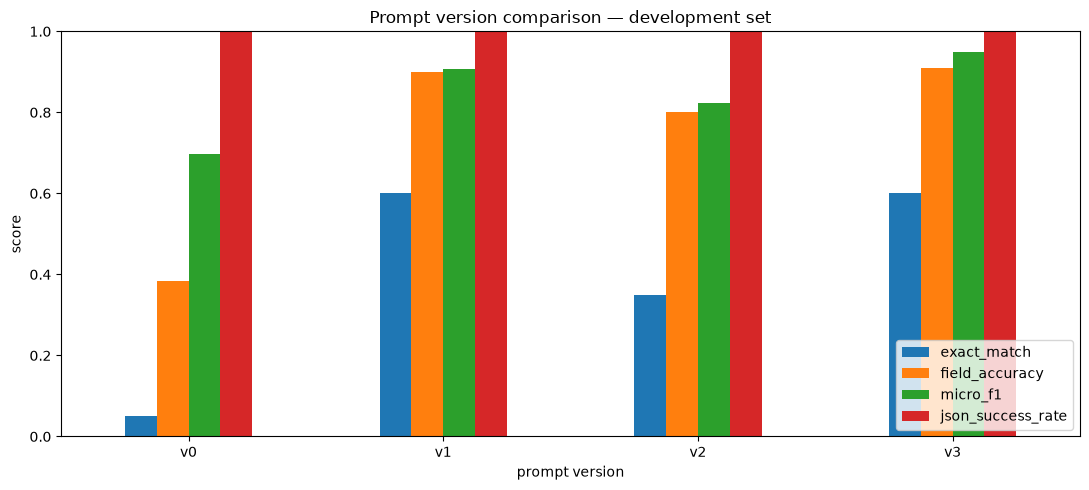

In [17]:
chart_columns = [
    "exact_match",
    "field_accuracy",
    "micro_f1",
    "json_success_rate",
]

ax = metrics_table[chart_columns].plot(kind="bar", figsize=(11, 5), ylim=(0, 1))
ax.set_title("Prompt version comparison — development set")
ax.set_ylabel("score")
ax.set_xlabel("prompt version")
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 7. 사례별 오류 분석

전체 점수만 확인하면 프롬프트 수정 이유를 설명하기 어렵다. 정답과 예측이 다른 사례를 아래 5개 오류 유형으로 분류한다.

- **누락 오류**: 정답에 있는 값을 예측이 빠뜨림
- **과잉 추론**: 정답에 없는 값을 예측이 추가함(입력에 없는 내용을 지어냄)
- **분류 오류**: 단일 값 필드(symptom_change, patient_present, guardian_only)를 다른 값으로 잘못 분류함
- **표현 오류**: 자유 서술 필드(subjective_summary, requested_consultation, soap_summary)의 내용이나 어투가 부적절함 — 자동 채점이 어려워 수동 확인 필요
- **형식 오류**: LLM 출력이 JSON으로 파싱되지 않음


In [18]:
def classify_error_types(record):
    prediction = record["prediction"]
    if prediction is None:
        return ["형식 오류"]

    gold = record["gold"]
    error_types = []

    for field in MULTI_LABEL_FIELDS:
        gold_set = set(gold.get(field) or [])
        predicted_set = set(prediction.get(field) or [])
        if gold_set - predicted_set:
            error_types.append("누락 오류")
        if predicted_set - gold_set:
            error_types.append("과잉 추론")

    for field in SINGLE_LABEL_FIELDS:
        gold_value = gold.get(field)
        predicted_value = prediction.get(field)
        if predicted_value == gold_value:
            continue
        if gold_value is not None and predicted_value is None:
            error_types.append("누락 오류")
        elif gold_value is None and predicted_value is not None:
            error_types.append("과잉 추론")
        else:
            error_types.append("분류 오류")

    return sorted(set(error_types))


def record_has_error(record):
    prediction = record["prediction"]
    if prediction is None:
        return True
    gold = record["gold"]
    for field in ALL_CLASSIFICATION_FIELDS:
        if not field_is_correct(field, prediction, gold):
            return True
    return False


def build_error_table(result):
    rows = []
    for record in result["records"]:
        if record_has_error(record):
            rows.append({
                "case_id": record["case_id"],
                "disease_context": record.get("disease_context", ""),
                "input": record["input"],
                "gold": json.dumps(record["gold"], ensure_ascii=False),
                "prediction": json.dumps(record["prediction"], ensure_ascii=False),
                "auto_error_types": ", ".join(classify_error_types(record)),
                "expression_check_needed": "표현 오류 수동 확인 필요",
                "manual_note": "직접 작성",
            })
    return pd.DataFrame(rows)


In [19]:
# 확인할 버전을 변경할 수 있습니다.
ERROR_VERSION = "v0"
error_table = build_error_table(development_results[ERROR_VERSION])
error_table


,case_id,disease_context,input,gold,prediction,auto_error_types,expression_check_needed,manual_note
0,case_001,치매,어머니는 오늘 못 오시고 저만 왔어요. 요양원에 낼 서류가 필요한데 뭘 떼야 하는지는 잘 모르겠어요. 그리고 요즘 식사를 하시고도 밥을 안 먹었다고 하시는 일이 자꾸 있어서 그것도 여쭤보고 싶어요.,"{""visit_purpose"": [""서류 발급"", ""증상 상담""], ""symptom_change"": ""나빠짐"", ""document_type"": [""기타/종류 모름""], ""document_destination""...","{""visit_purpose"": [""서류 발급"", ""증상 상담""], ""document_type"": [], ""document_destination"": [], ""symptom_change"": null, ""pati...",누락 오류,표현 오류 수동 확인 필요,직접 작성
1,case_002,파킨슨병,약은 그대로 받을게요. 그런데 요즘 손 떨림이 오전에는 괜찮다가 오후만 되면 심해져요. 저녁때는 수저 들기가 힘들 때도 있고요. 혼자 왔습니다.,"{""visit_purpose"": [""약 처방"", ""증상 상담""], ""symptom_change"": ""나빠짐"", ""document_type"": [], ""document_destination"": [], ""pati...","{""visit_purpose"": [""약 처방""], ""document_type"": [], ""document_destination"": [], ""symptom_change"": ""나빠짐"", ""patient_prese...",누락 오류,표현 오류 수동 확인 필요,직접 작성
2,case_003,뇌전증,"지난달에 학교 낼 진단서는 받아 갔고요, 요즘 발작 횟수가 좀 는 것 같아서 왔어요. 엄마랑 같이 왔습니다.","{""visit_purpose"": [""증상 상담""], ""symptom_change"": ""나빠짐"", ""document_type"": [], ""document_destination"": [], ""patient_pres...","{""visit_purpose"": [""증상 상담"", ""서류 발급""], ""document_type"": [""진단서""], ""document_destination"": [""직장/학교""], ""symptom_change"":...","과잉 추론, 누락 오류, 분류 오류",표현 오류 수동 확인 필요,직접 작성
3,case_004,치매,"아버지 모시고 같이 왔어요. 지난번 검사 결과 들으러 왔고, 보험에 낼 소견서도 하나 부탁드립니다.","{""visit_purpose"": [""검사결과 확인"", ""서류 발급""], ""symptom_change"": null, ""document_type"": [""소견서""], ""document_destination"": [""...","{""visit_purpose"": [""검사결과 확인"", ""서류 발급""], ""document_type"": [""소견서""], ""document_destination"": [""보험""], ""symptom_change"": ...","과잉 추론, 누락 오류",표현 오류 수동 확인 필요,직접 작성
4,case_005,파킨슨병,"아버지는 거동이 불편하셔서 저만 왔어요. 장애 등급 신청을 하려는데 어떤 서류를 떼야 하는지 모르겠어요. 그리고 요즘 걸음이 많이 느려지셨어요. 발이 잘 안 떨어진다고 하시고, 집 안에서도 몇 번 넘어질 뻔했어요.","{""visit_purpose"": [""서류 발급"", ""증상 상담""], ""symptom_change"": ""나빠짐"", ""document_type"": [""기타/종류 모름""], ""document_destination""...","{""visit_purpose"": [""서류 발급"", ""증상 상담""], ""document_type"": [], ""document_destination"": [], ""symptom_change"": ""['나빠짐']"", ...","누락 오류, 분류 오류",표현 오류 수동 확인 필요,직접 작성
5,case_006,뇌전증,약만 타러 왔어요. 별다른 건 없었고요. 혼자 왔습니다.,"{""visit_purpose"": [""약 처방""], ""symptom_change"": ""비슷함"", ""document_type"": [], ""document_destination"": [], ""patient_prese...","{""visit_purpose"": [""약 처방""], ""document_type"": [], ""document_destination"": [], ""symptom_change"": ""비슷함"", ""patient_prese...",누락 오류,표현 오류 수동 확인 필요,직접 작성
6,case_007,치매,어머니 모시고 같이 왔어요. 요즘 밤에 자꾸 깨서 집 안을 돌아다니세요. 새벽에 현관문을 열려고 하신 적도 있고요. 이게 약 때문인지 다른 이유인지 상담받고 싶어요.,"{""visit_purpose"": [""증상 상담""], ""symptom_change"": ""새 증상 있음"", ""document_type"": [], ""document_destination"": [], ""patient_...","{""visit_purpose"": [""증상 상담""], ""document_type"": [], ""document_destination"": [], ""symptom_change"": ""잘 모르겠음"", ""patient_p...","누락 오류, 분류 오류",표현 오류 수동 확인 필요,직접 작성
7,case_011,파킨슨병,"아이고 오늘 주차장이 왜 이렇게 복잡해요. 아버지 약 타러 왔는데요, 참 그리고 저번에 새로 바꾼 약 있잖아요, 그거 먹고부터 자꾸 어지럽다고 하셔가지고. 아 아버지도 같이 왔어요, 지금 화장실 가셨고요. 어...","{""visit_purpose"": [""약 처방"", ""증상 상담""], ""symptom_change"": ""새 증상 있음"", ""document_type"": [], ""document_destination"": [], ""...","{""visit_purpose"": [""약 처방""], ""document_type"": [], ""document_destination"": [], ""symptom_change"": ""새 증상 있음"", ""patient_p...",누락 오류,표현 오류 수동 확인 필요,직접 작성
8,case_013,치매,어무이 모시고 왔심더. 요새 자꾸 화를 내시고 예전엔 안 그랬거든예. 밤에 잠도 잘 몬 주무시고. 그거 때문에 상담 좀 받아볼라꼬예.,"{""visit_purpose"": [""증상 상담""], ""symptom_change"": ""새 증상 있음"", ""document_type"": [], ""document_destination"": [], ""patient_...","{""visit_purpose"": [""증상 상담""], ""document_type"": [], ""document_destination"": [], ""symptom_change"": ""새 증상 있음"", ""patient_...",누락 오류,표현 오류 수동 확인 필요,직접 작성
9,case_014,파킨슨병,"소견서 하나 떼려고요. 아 잠깐, 소견서가 아니고 진단서라 했나... 보험회사에서 달라는 거요. 몸은 뭐 비슷해요. 혼자 왔어요.","{""visit_purpose"": [""서류 발급""], ""symptom_change"": ""비슷함"", ""document_type"": [""기타/종류 모름""], ""document_destination"": [""보험""],...","{""visit_purpose"": [""서류 발급""], ""document_

### 수동 평가 기준

대표 사례에는 다음 항목을 0점 또는 1점으로 기록한다.

- 원문의 사실을 보존했는가
- 입력에 없는 사실을 생성하지 않았는가
- 불확실성을 확정적으로 바꾸지 않았는가
- 진료 전 확인 자료로 활용 가능한가

### 대표 사례 수동 채점 (v3, 개발 세트 20케이스 실행 기준)

| 사례 | 사실 보존 | 환각 없음 | 불확실성 유지 | 활용 가능 | 메모 |
|---|---|---|---|---|---|
| case_001 (실패) | 0 | 0 | 1 | 0 | "저만 왔어요"를 "환자 본인이 내원함"으로 기재 — 입력에 없는 사실이 생성되고 보호자 전달 내용이라는 표시도 사라짐. 방문 형태 오판 하나가 요약 전체에 전파되는 사례. |
| case_013 (성공, 사투리) | 1 | 1 | 1 | 1 | 경상 사투리 입력에서도 화냄·수면 문제를 보호자 전달로 정확히 구조화. 표현 다양성 자체는 장벽이 아님. |
| case_019 (부분 실패) | 1 | 1 | 1 | 0 | 사실 왜곡은 없으나 requested_consultation이 null — 말수 감소를 상담하고 싶다는 의사가 누락되고 P도 "없음"으로 비어, 진료 전 확인 자료로는 불완전. 다중 요청(4개) 케이스에서 상담 항목이 밀려나는 패턴. |


## 8. 개발 결과 저장

개발 세트의 지표표는 `results/metrics_summary.csv`에 저장한다(매 실행마다 최신 결과로 덮어씀). 상세 원본 응답은 `results/raw/`에 타임스탬프 파일로 남긴다. 저장 파일은 Git 커밋 전에 개인정보 포함 여부를 다시 확인한다.


In [20]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
raw_json_path = RAW_DIR / f"{timestamp}_development_results.json"

with raw_json_path.open("w", encoding="utf-8") as file:
    json.dump(development_results, file, ensure_ascii=False, indent=2)

metrics_table.to_csv(RESULTS_DIR / "metrics_summary.csv", encoding="utf-8-sig")

print("상세 원본(raw):", raw_json_path)
print("지표 요약(포트폴리오용):", RESULTS_DIR / "metrics_summary.csv")


상세 원본(raw): /Users/mac/Documents/Project/outpatient-ai-lab/results/raw/20260709_233306_development_results.json
지표 요약(포트폴리오용): /Users/mac/Documents/Project/outpatient-ai-lab/results/metrics_summary.csv


## 9. 최종 시험 세트 평가

개발 세트에서 프롬프트를 수정한 뒤 최종 버전 하나를 선택한다. 시험 세트에서는 여러 버전을 비교해 다시 선택하지 않는다.

In [21]:
# 개발 결과를 확인한 후 최종 버전을 직접 지정합니다.
FINAL_VERSION = "v3"

test_result = run_experiment(FINAL_VERSION, split="test")
pd.DataFrame([{**test_result["metrics"], "version": FINAL_VERSION}]).set_index("version")

[v3] 1/10 case_008


[v3] 2/10 case_009


[v3] 3/10 case_010


[v3] 4/10 case_024


[v3] 5/10 case_025


...

[v3] 7/10 case_027


[v3] 8/10 case_028


[v3] 9/10 case_029


[v3] 10/10 case_030


,case_count,json_success_rate,exact_match,field_accuracy,micro_precision,micro_recall,micro_f1,omission_rate,hallucination_rate,input_tokens,output_tokens,symptom_change_accuracy,patient_present_accuracy,guardian_only_accuracy
version,,,,,,,,,,,,,,
v3,10,1.0,0.4,0.833333,0.939394,0.885714,0.911765,0.114286,0.060606,12800,1744,0.6,1.0,1.0


In [22]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
raw_test_path = RAW_DIR / f"{timestamp}_{FINAL_VERSION}_test.json"

with raw_test_path.open("w", encoding="utf-8") as file:
    json.dump(test_result, file, ensure_ascii=False, indent=2)

final_error_table = build_error_table(test_result)
final_error_table.to_csv(RESULTS_DIR / "error_analysis.csv", index=False, encoding="utf-8-sig")

print("상세 원본(raw):", raw_test_path)
print("최종 오류 분석(포트폴리오용):", RESULTS_DIR / "error_analysis.csv")


상세 원본(raw): /Users/mac/Documents/Project/outpatient-ai-lab/results/raw/20260709_233341_v3_test.json
최종 오류 분석(포트폴리오용): /Users/mac/Documents/Project/outpatient-ai-lab/results/error_analysis.csv


## 10. 결과 해석

2차 실행(30케이스: 개발 20/시험 10, gpt-4.1-mini) 기준. 1차 파일럿(10케이스) 결과와의 비교는 마지막에 정리한다.

### 기준선 (v0)
- Exact Match 5%, Field Accuracy 38.3%, Micro F1 0.698, 누락률 38.8%, 환각률 18.9%
- 어떤 필드를 뽑아야 하는지 정해주지 않으면 방문 형태 정확도가 5%까지 떨어지고, 문장이 지저분해지면 입력에 없는 내용을 지어내는 답(환각)도 나오기 시작한다.

### 버전 비교의 반전 — 규칙을 더한다고 항상 좋아지지 않는다
- v1(필드·허용값 명시): Exact Match 60%, Field Accuracy 90.0% — 출력할 필드와 고를 수 있는 값을 정해준 것만으로 가장 큰 폭의 개선.
- v2(불확실성 규칙 추가): Exact Match 35%로 **v1보다 하락**. '말하지 않은 내용은 채우지 말고 비워두라'는 규칙을 넣었더니, 문장이 지저분한 경우에는 분명히 말한 내용(같이 왔는지, 증상이 어떤지)까지 비워버렸다. 파일럿에서 방문 형태 정확도 하락(85.7%→57.1%)으로 조짐이 보였던 부작용이, 케이스가 어려워지자 크게 드러난 것.
- v3(도메인 규칙): Exact Match 60%(v1과 동률), Field Accuracy 90.8%, Micro F1 0.949(최고), 누락률 4.1%(최저). 진료 전 문진에서는 놓치는 정보를 최소화하는 것이 가장 중요하므로 v3를 최종 선택. 대신 프롬프트가 길어져 입력 토큰이 v0의 약 4배가 든다.

### 남은 오류의 구조
1. **증상 변화 경계(나빠짐 vs 새 증상 있음)** — 가장 많이 틀린 항목. 악화를 새 증상으로 보기도 하고(016, 025), 새 증상을 악화로 보기도 했다(019, 027, 029). 정답 라벨을 만들 때 사람도 고민했던 경계라서, 프롬프트가 아니라 선택지 체계 자체의 문제로 판단 — '양상 변화 있음' 같은 중간 선택지 신설 또는 경계 예시 보강이 다음 개선 후보.
2. **서류 발급 vs 검사결과 확인 혼동**(008, 023) — "결과지를 받으러 왔다"(종이 발급 요청)에 '검사결과 확인'이라는 목적을 멋대로 추가함. 두 번의 실행에서 반복된 패턴이라 다음 프롬프트 개선의 1순위 대상.
3. **다중 요청 처리**(010, 019, 029, 030) — 한 번에 요청이 3개 이상 겹치면 일부를 빠뜨리거나(서류·상담 항목), 반대로 말하지 않은 목적을 추가함(030의 '약 처방').
4. **case_001 반복 실패** — "저만 왔어요"를 이번에도 환자 본인이 온 것으로 잘못 판단. 같은 입력이라도 실행할 때마다 답이 조금씩 달라지는 LLM의 특성(비결정성) 때문에, smoke test에서는 맞혔던 케이스를 본 실행에서는 틀렸다. 방문 형태처럼 틀리면 안 되는 항목은 프롬프트에만 맡기지 말고, 문진 화면에서 직접 선택한 값(3번 문항)을 우선 적용하는 안전장치가 필요하다는 근거.

### 성공 지점
- 시험 세트 방문 형태 정확도 100% — "엄마가 요양원에 계셔서 오늘도 저 혼자 왔어요"(027) 같은 헷갈리는 표현을 통과.
- 사투리 케이스(013 경상, 024 전라)도 정확히 정리함 — 말투나 지역 표현 자체는 장벽이 아님.
- 012("약이요. 그대로예요.")에서 patient_present를 비워둠(null) — 말하지 않은 정보를 채우지 않는 규칙이 일부 작동함(guardian_only는 False로 채워서 절반의 성공).

### 시험 세트 (v3, 10케이스, 1회 평가)
- Exact Match 40%, Field Accuracy 83.3%, Micro F1 0.912, 누락률 11.4%, 환각률 6.1%
- 방문 형태·동행 정확도는 100%. symptom_change 정확도 60%가 주된 하락 요인 — 개발 세트와 같은 경계 문제다.

### 1차 파일럿(10케이스) 대비
- 파일럿에서 v3는 개발 세트 Exact Match 85.7%, Micro F1 1.000이었으나, 지저분한 문장·드물게 나오는 라벨(좋아짐, 잘 모르겠음, 언급 없음)·다중 요청을 넣자 60%/0.949로 내려왔다.
- 쉬운 문제에서 점수가 높다고 어려운 문제도 잘 푸는 것은 아니라는 점을 확인 — 케이스 확장의 목적이 바로 이 차이를 드러내는 것이었고, 남은 오류가 특정 유형(증상 경계, 발급/확인, 다중 요청)에 몰려 있어 다음에 무엇을 고쳐야 하는지가 분명해졌다.

### 한계
- 30케이스(개발 20/시험 10) 합성 평가이며 실제 외래에서 나오는 표현 분포를 대표하지 않는다.
- 최종 판단을 위한 임상 성능 평가가 아니라 정보 추출 프로토타입 평가다.
- 1회 실행 결과이며, temperature 기본값에서는 같은 입력이라도 실행마다 결과가 달라질 수 있다(case_001이 그 예).
- 정답(gold) 라벨을 한 사람(작성자)이 만들었다. 증상 변화 경계처럼 평가자마다 판단이 갈릴 수 있는 항목이 실제로 확인됐다.


## 11. LangSmith 실험 기록 (선택)

`.env`에 `LANGSMITH_API_KEY`가 있을 때만 실행한다. 없으면 이 섹션은 건너뛴다.

- 개별 호출 트레이스(토큰·지연시간·프롬프트 원문)는 위 실행에서 이미 자동 기록되었다(1번 섹션에서 클라이언트를 래핑했기 때문).
- 아래 셀은 개발 세트 gold를 LangSmith 데이터셋으로 올리고, **위 실행에서 저장된 예측을 API 재호출 없이** 버전별 실험(experiment)으로 기록한다. 실행 후 LangSmith의 Dataset > Experiments 화면에서 v0~v3를 나란히 비교할 수 있다.

In [23]:
from langsmith import Client as LangSmithClient

ls_client = LangSmithClient()
DATASET_NAME = "opd-intake-dev"

if ls_client.has_dataset(dataset_name=DATASET_NAME):
    dataset = ls_client.read_dataset(dataset_name=DATASET_NAME)
    print("기존 데이터셋 사용:", DATASET_NAME)
else:
    dataset = ls_client.create_dataset(
        dataset_name=DATASET_NAME,
        description="신경과 재진 외래 문진 합성 케이스 — 개발 세트",
    )
    development_cases = [case for case in EVAL_CASES if case["split"] == "development"]
    ls_client.create_examples(
        dataset_id=dataset.id,
        inputs=[
            {"case_id": case["case_id"], "disease_context": case["disease_context"], "input": case["input"]}
            for case in development_cases
        ],
        outputs=[case["gold"] for case in development_cases],
    )
    print("데이터셋 생성:", DATASET_NAME, f"({len(development_cases)}건)")

데이터셋 생성: opd-intake-dev (20건)


In [24]:
from langsmith import evaluate


def make_target(version):
    predictions = {record["case_id"]: record["prediction"] for record in development_results[version]["records"]}

    def target(inputs):
        return predictions.get(inputs["case_id"]) or empty_prediction()

    return target


def exact_match_evaluator(outputs, reference_outputs):
    score = all(field_is_correct(field, outputs, reference_outputs) for field in ALL_CLASSIFICATION_FIELDS)
    return {"key": "exact_match", "score": float(score)}


def field_accuracy_evaluator(outputs, reference_outputs):
    correct = sum(field_is_correct(field, outputs, reference_outputs) for field in ALL_CLASSIFICATION_FIELDS)
    return {"key": "field_accuracy", "score": correct / len(ALL_CLASSIFICATION_FIELDS)}


for version in PROMPT_VERSIONS:
    evaluate(
        make_target(version),
        data=DATASET_NAME,
        evaluators=[exact_match_evaluator, field_accuracy_evaluator],
        experiment_prefix=f"{version}-dev",
        metadata={"prompt_version": version, "model": MODEL},
    )

print("LangSmith 실험 기록 완료 — Dataset > Experiments에서 v0~v3 비교")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


View the evaluation results for experiment: 'v0-dev-8f56e1df' at:
https://smith.langchain.com/o/8083b62f-af73-4bef-9055-d3da1488a4e5/datasets/90495f7f-a27d-4915-a7a7-559892f96d43/compare?selectedSessions=4f4be1f4-ed01-4dea-aeea-05618863b78b




0it [00:00, ?it/s]

20it [00:00, 74.43it/s]

View the evaluation results for experiment: 'v1-dev-8c31c66c' at:
https://smith.langchain.com/o/8083b62f-af73-4bef-9055-d3da1488a4e5/datasets/90495f7f-a27d-4915-a7a7-559892f96d43/compare?selectedSessions=462c9b3c-5324-4d0b-9b27-34456bd6d2f9




...

20it [00:00, 79.11it/s]

View the evaluation results for experiment: 'v3-dev-a8c05918' at:
https://smith.langchain.com/o/8083b62f-af73-4bef-9055-d3da1488a4e5/datasets/90495f7f-a27d-4915-a7a7-559892f96d43/compare?selectedSessions=ebbde97b-9066-42ea-bbbc-d057b9fe5b73




0it [00:00, ?it/s]

20it [00:00, 79.20it/s]

LangSmith 실험 기록 완료 — Dataset > Experiments에서 v0~v3 비교


# 결론

이 노트북의 완료 기준은 v0~v3 점수표, 대표 오류 분석, 최종 버전 선정 근거, 시험 세트 결과가 모두 남는 것이다. LangSmith 연동 시 같은 데이터셋과 평가 함수가 실험 관리 화면에 기록되어 버전 비교를 화면으로 확인할 수 있다.